# CUSTOMER CHURN PREDICTION USING MACHINE LEARNING

## Problem Statement 
The goal of this project is to predict whether a customer will leave (churn) a telecom service based on customer demographic and service usage data.

## Objective
- Perform data cleaning and exploration
- Identify factors affecting churn
- Build a Machine Learning classification model
- Evaluate model performance
  
## Target Variable
Churn (Yes/No)

### 1. Importing Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pd.set_option('display.max_column',None)

### 2. Load Churn Dataset

In [40]:
churn_dataset = pd.read_csv("../data/Telco_Customer_Churn.csv")
churn_dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [41]:
churn_dataset.shape

(7043, 21)

In [42]:
churn_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [43]:
churn_dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [44]:
churn_dataset.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [45]:
churn_dataset.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

### INITIAL OBSERVATION:
1. DATASET SIZE:
   * The dataset contains <b>7043 CUSTOMERS </b>records and <B> 21 FEATURES </B>describing customer demographics, services used, and billing
information.


2. DATA TYPE:

   * The dataset contains both categorical and numerical variables
   * Numerical columns include: SeniorCitizen, tenure, MonthlyCharges
   * Most other columns are categorical (object type) and represent customer service details.

3. MISSING VALUES:
   * No missing values were detected across the dataset using isnull().sum().
  
4. CUSTOMER BILLING:

   * The average monthly charge is around 64.
   * Monthly charges range from approximately 18 to 118.

5. CUSTOMER TENURE:

   * Customers stay with the company for an average of around 32 months.
   * The tenure ranges from 0 to 72 months, indicating both new and long-term customers.


### 3. DATA CLEANING

In [46]:
churn_dataset.duplicated().sum()

0

In [47]:
# Converts values to numbers
churn_dataset['TotalCharges'] = pd.to_numeric(churn_dataset['TotalCharges'], errors='coerce')

In [48]:
churn_dataset.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [49]:
# Handling Missing Values

In [50]:
churn_dataset = churn_dataset.dropna()

In [51]:
churn_dataset.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [52]:
churn_dataset.drop('customerID', axis=1, inplace=True)

In [53]:
churn_dataset.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


### 4. EDA Visualization

In [54]:
churn_dataset['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [55]:
churn_dataset['Churn'].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

### OBSERVATION:
* Around 26.5% of customers have churned, while 73.5% remained with the company.

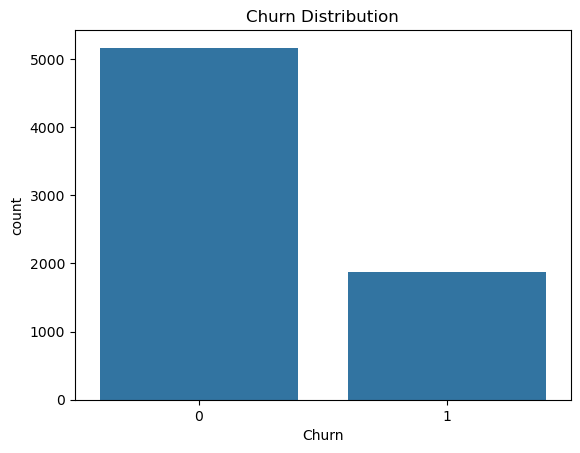

In [91]:
#Churn Distribution

sns.countplot(x='Churn', data=churn_dataset)
plt.title("Churn Distribution")

plt.savefig("churn_distribution.png")
plt.show()

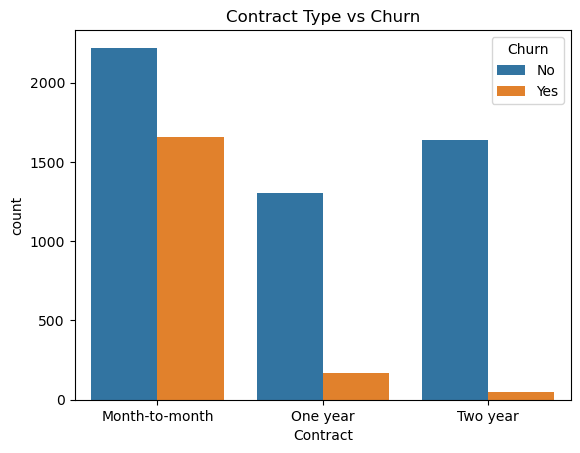

In [57]:
# Contract Type vs Churn

sns.countplot(x='Contract', hue='Churn', data=churn_dataset)
plt.title("Contract Type vs Churn")
plt.show()

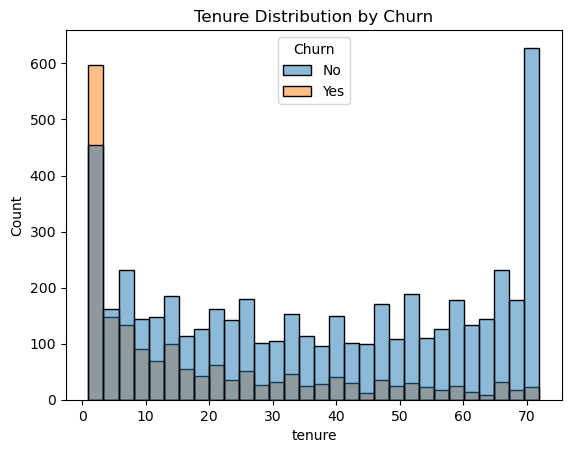

In [58]:
# Tenure vs Churn

sns.histplot(x='tenure',hue= 'Churn', data = churn_dataset, bins = 30)
plt.title("Tenure Distribution by Churn")
plt.show()

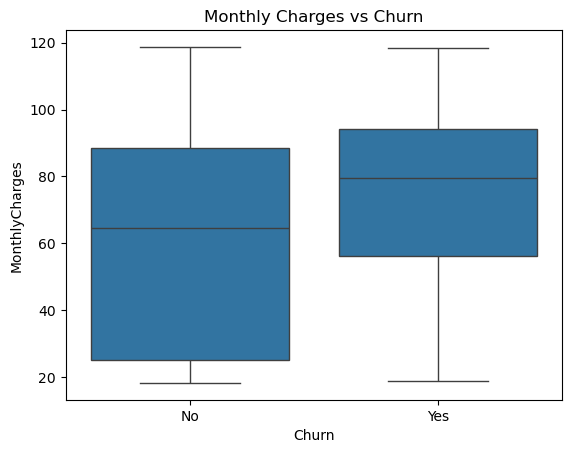

In [59]:
# Monthly Charges vs Churn

sns.boxplot(data = churn_dataset, x='Churn', y='MonthlyCharges')
plt.title("Monthly Charges vs Churn")
plt.show()

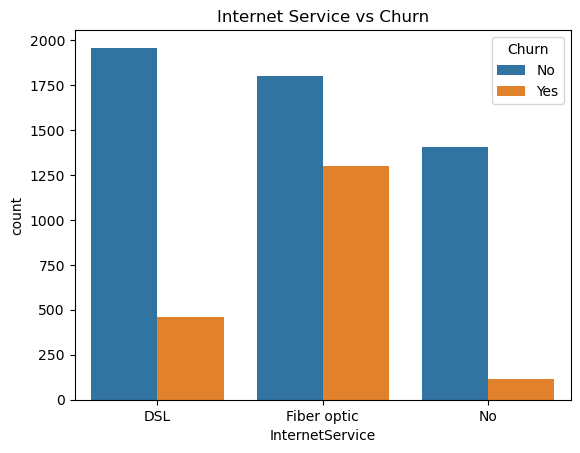

In [60]:
# Internet Service vs Churn

sns.countplot(x='InternetService', hue='Churn', data=churn_dataset)
plt.title("Internet Service vs Churn")
plt.show()

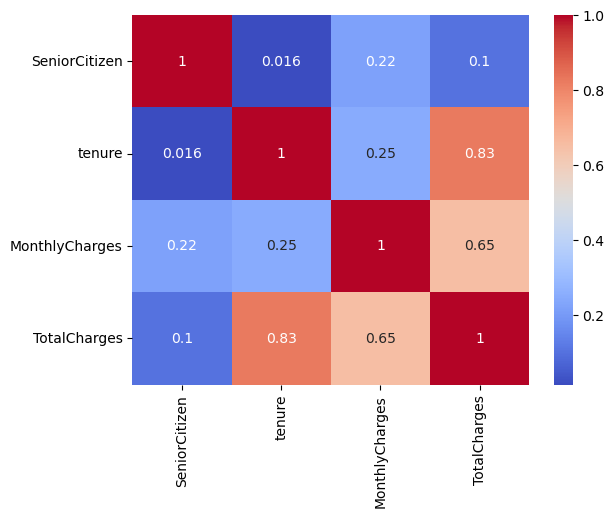

In [61]:
# Correlation Heatmap

sns.heatmap(churn_dataset.corr(numeric_only=True),annot=True, cmap='coolwarm')
plt.show()

#### INSIGHTS:
* Majority of customers did not churn.
* Month-to-month customers churn the most AND Two-year contract customers churn the least
* Customers with low tenure churn more
* Customers paying higher monthly charges tend to churn more.

### 5. Feature Engineering 

In [62]:
churn_dataset.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [63]:
# converting target variable(Churn)

churn_dataset['Churn'] = churn_dataset['Churn'].map({'Yes':1, 'No':0})

In [64]:
churn_dataset.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
5,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,0
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,0
8,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
9,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,0


In [65]:
# Converting Binary Columns (Partner,Dependents,PhoneService,PaperlessBilling)

binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling']

for col in binary_cols:
    churn_dataset[col] = churn_dataset[col].map({'Yes':1, 'No':0})


In [66]:
churn_dataset.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [67]:
# One-Hot Encoding for Multi Categories (InternetService, Contract, PaymentMethod)

churn_dataset = pd.get_dummies(churn_dataset, drop_first=True)

In [68]:
churn_dataset.head(5)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,True,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,2,1,1,70.70,151.65,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [69]:
# Define Target and Feature

x = churn_dataset.drop('Churn', axis=1)
y = churn_dataset['Churn']

In [70]:
# Train Test Split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

### 6. Train Logistic Regression Model

In [71]:
model = LogisticRegression()

In [72]:
model.fit(x_train, y_train)

C:\Users\AVANTHEKA.S\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [73]:
y_pred = model.predict(x_test)

In [74]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7867803837953091


In [75]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [76]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[919 114]
 [186 188]]


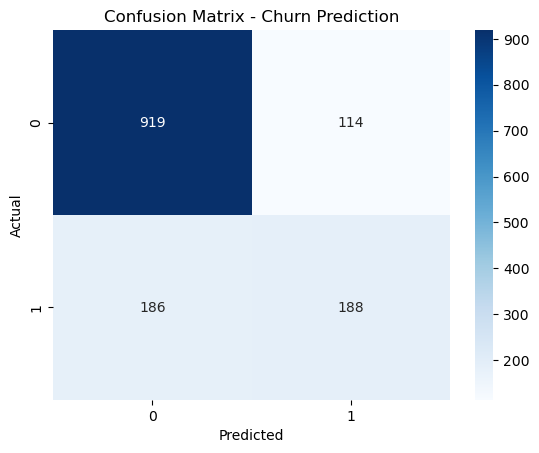

In [90]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Churn Prediction")

plt.savefig("confusion_matrix.png")

plt.show()

### 7. Improve model - Random Forest

In [78]:
rf_model = RandomForestClassifier(random_state=42)

In [79]:
rf_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [80]:
y_pred_rf = rf_model.predict(x_test)

In [81]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7853589196872779


In [82]:
confusion_matrix(y_test, y_pred_rf)

array([[933, 100],
       [202, 172]], dtype=int64)

In [83]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.46      0.53       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



### 8. Handling class Imbalance

In [84]:
RandomForestClassifier(class_weight='balanced')

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [87]:
feature_importance = pd.Series(rf_model.feature_importances_, index=x.columns)
feature_importance.sort_values(ascending=False).head(10)

TotalCharges                      0.197029
MonthlyCharges                    0.171905
tenure                            0.168964
InternetService_Fiber optic       0.038095
PaymentMethod_Electronic check    0.037654
Contract_Two year                 0.029282
gender_Male                       0.027844
OnlineSecurity_Yes                0.027362
PaperlessBilling                  0.025299
Contract_One year                 0.024459
dtype: float64

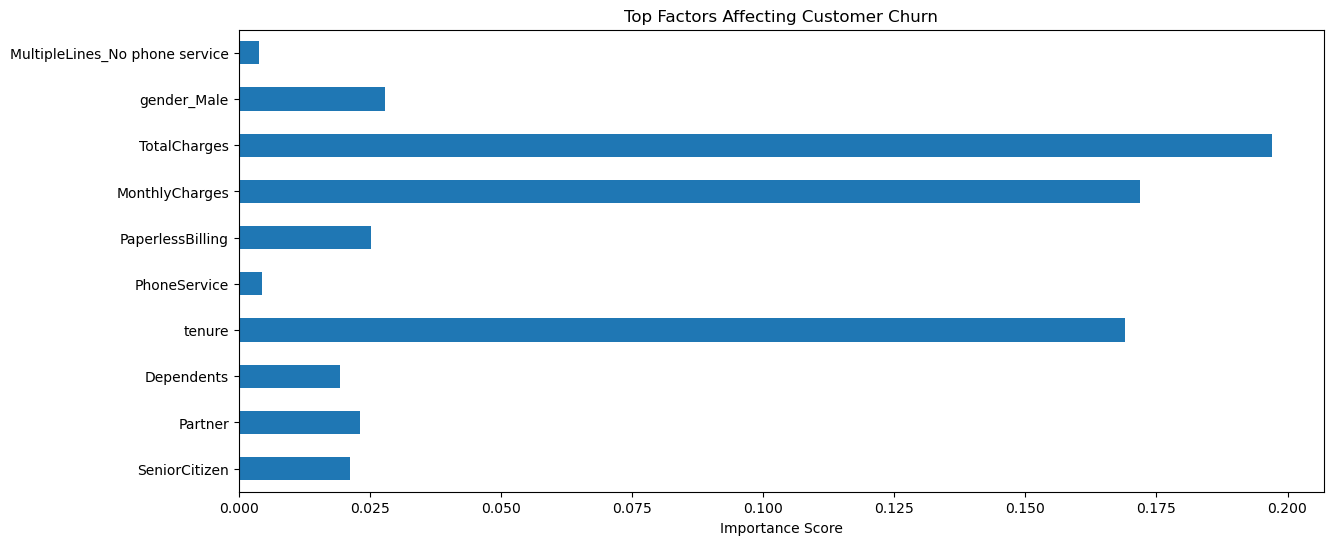

In [97]:
plt.figure(figsize=(14,6))

feature_importance.head(10).plot(kind='barh')

plt.title("Top Factors Affecting Customer Churn")
plt.xlabel("Importance Score")

plt.savefig("feature_importance.png")

plt.show()

## Insights
* Customers with high monthly charges are more likely to churn.
* Customers with low tenure have a higher probability of leaving.
* Billing preferences (like paperless billing) slightly influence churn.

## Recommendations For This Business
* Offering discounts for high monthly charge customers
* Creating loyalty programs for new customers
* Providing contract-based plans to increase retention
* Monitoring customers with rapidly increasing total charges

## CONCLUSION

This research employed machine learning methodologies to forecast customer attrition in a telecommunications dataset. Random Forest and Logistic Regression models were constructed and assessed. The accuracy of the model was about 78%. According to a feature importance analysis, the most significant elements influencing churn are Monthly Charges, Total Charges, and Tenure. These insights can help telecom companies identify high-risk customers and implement targeted retention strategies.